# 1.Introduction

In this tutorial investigates how Principal Component Analysis (PCA) improves K-Means clustering.

K-Means is sensitive to high-dimensional and correlated data. PCA reduces dimensionality and removes redundancy, improving clustering quality.

We compare clustering performance before and after PCA.

# 2.Import Libraries

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples

plt.rcParams["figure.figsize"] = (8,6)
plt.rcParams["figure.dpi"] = 120
sns.set_style("whitegrid")

# 3. Load & Prepare Data
We remove irrelevant columns and keep only numerical features for clustering.

In [15]:
df = pd.read_csv("WineQT.csv")

if "Id" in df.columns:
    df = df.drop(columns=["Id"])

if "quality" in df.columns:
    df_features = df.drop(columns=["quality"])
else:
    df_features = df.copy()

df_features = df_features.dropna()
print("Dataset shape:", df_features.shape)

Dataset shape: (1143, 11)


# 4. Feature Scaling
Scaling ensures all features contribute equally to distance calculations in K-Means.

In [16]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_features)

# 5. Correlation Heatmap
The heatmap shows relationships between features. High correlation indicates redundancy, motivating PCA.

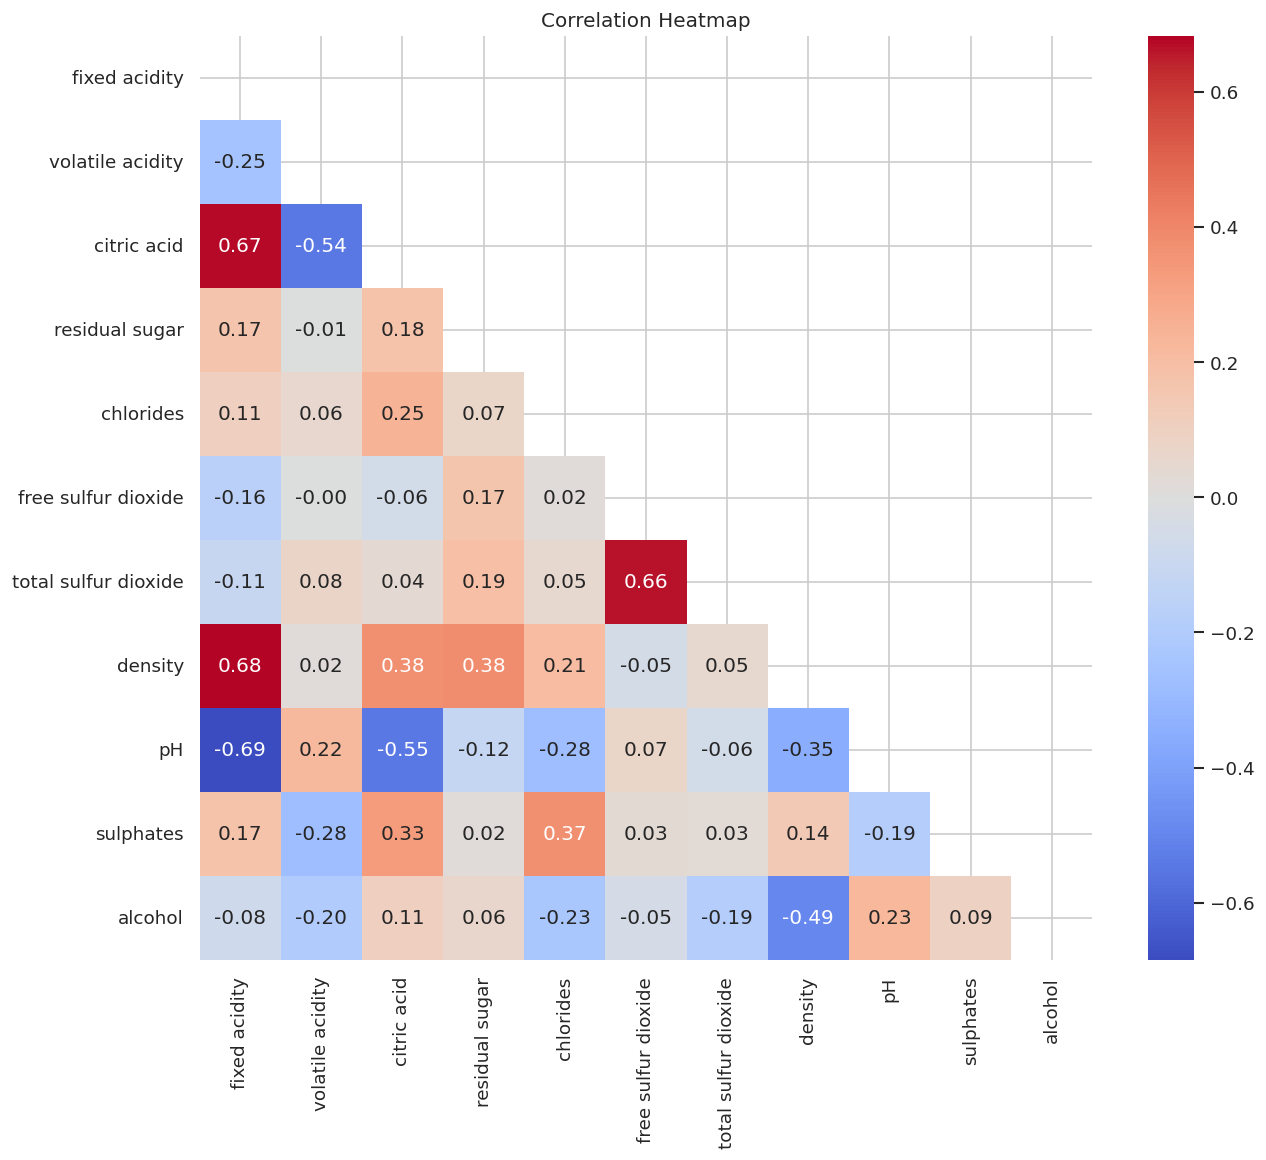

In [17]:
corr = df_features.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(12,10))
sns.heatmap(corr, mask=mask, cmap="coolwarm", annot=True, fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

# 6. Elbow Method
Used to estimate the optimal number of clusters.

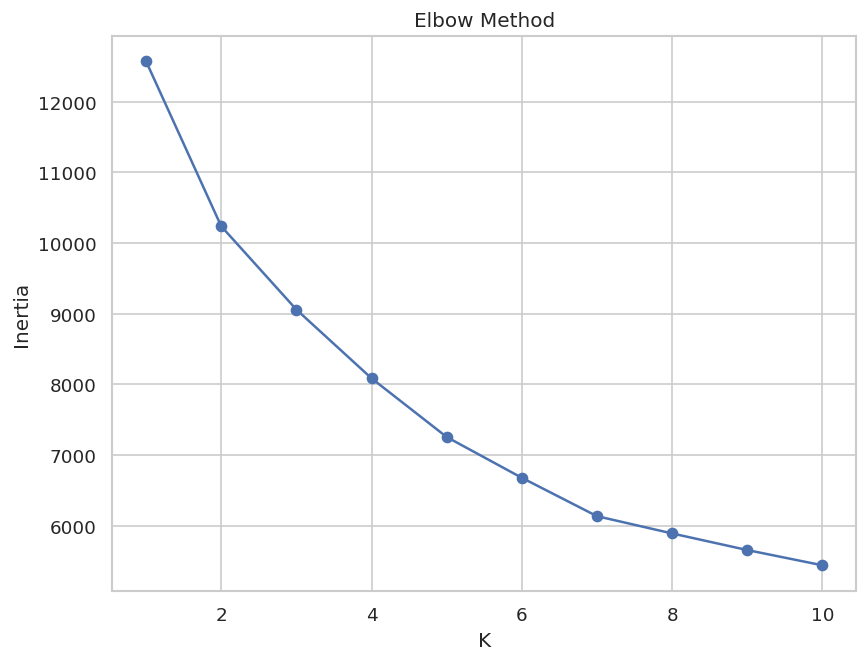

In [18]:
inertia = []
K_range = range(1, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(scaled_data)
    inertia.append(km.inertia_)

plt.plot(K_range, inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("K")
plt.ylabel("Inertia")
plt.show()

# 7. Silhouette Analysis
Measures how well-separated clusters are. Higher values indicate better clustering.

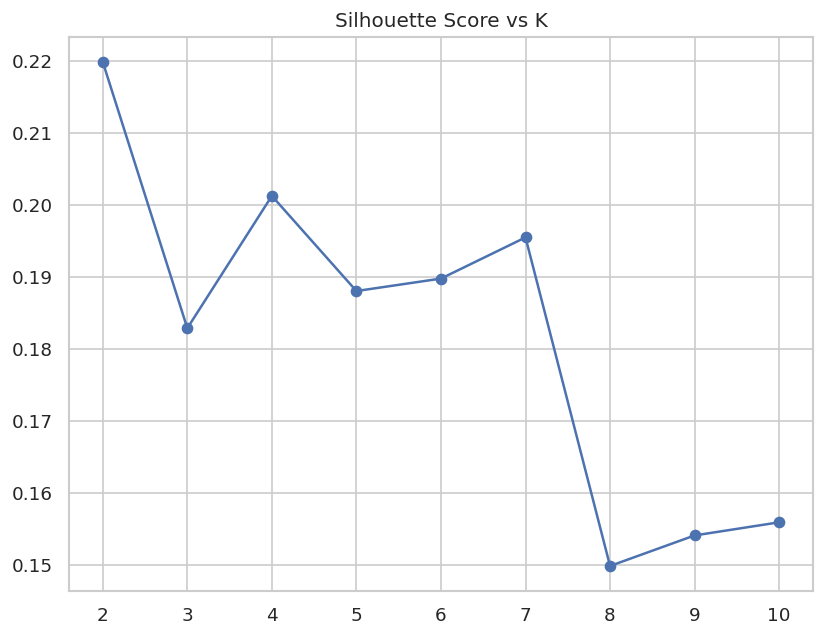

Optimal K: 2


In [19]:
sil_scores = []
K_range_sil = range(2, 11)

for k in K_range_sil:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_temp = km.fit_predict(scaled_data)
    score = silhouette_score(scaled_data, labels_temp)
    sil_scores.append(score)

plt.plot(K_range_sil, sil_scores, marker='o')
plt.title("Silhouette Score vs K")
plt.show()

optimal_k = K_range_sil[np.argmax(sil_scores)]
print("Optimal K:", optimal_k)

# 8. Clustering Before PCA
Clustering is applied on original features to observe limitations.

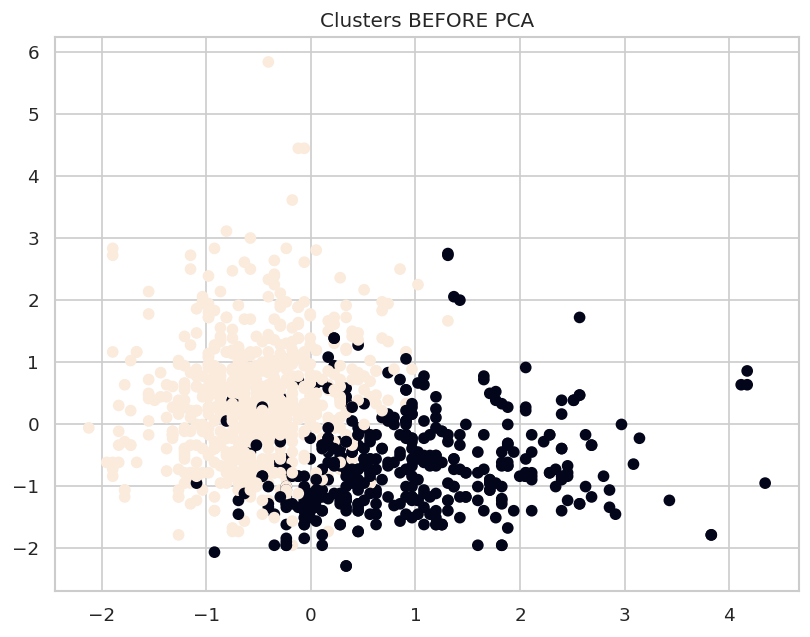

In [20]:
kmeans_raw = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
labels_raw = kmeans_raw.fit_predict(scaled_data)

plt.scatter(scaled_data[:,0], scaled_data[:,1], c=labels_raw)
plt.title("Clusters BEFORE PCA")
plt.show()

# 9. PCA Analysis
PCA reduces dimensionality while preserving variance.

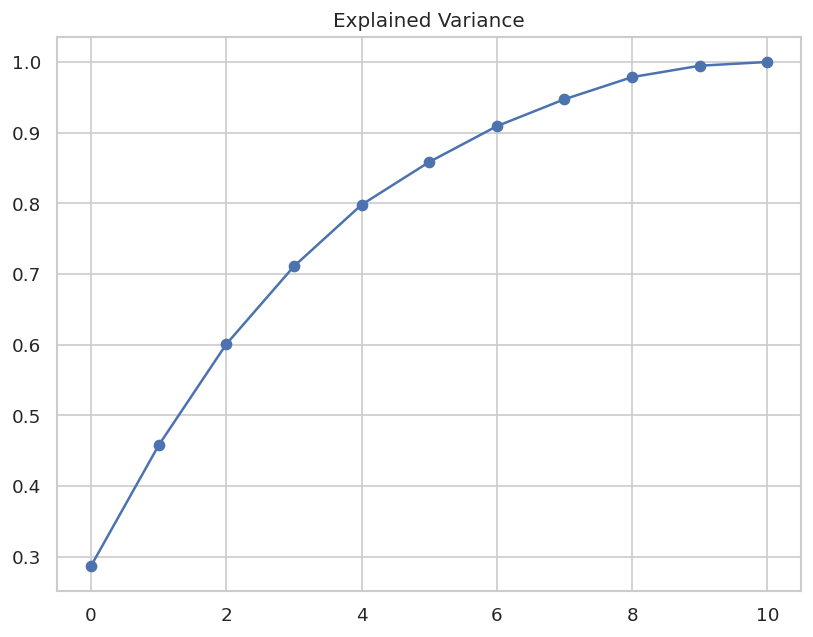

In [21]:
pca = PCA()
pca.fit(scaled_data)

plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.title("Explained Variance")
plt.show()

# 10. PCA Reduction
Data is reduced to 2 components for visualization.

In [22]:
pca_2 = PCA(n_components=2)
pca_data = pca_2.fit_transform(scaled_data)

print("Variance retained:", np.sum(pca_2.explained_variance_ratio_))

Variance retained: 0.45767448472769046


# 11. Clustering After PCA
Clustering in reduced space improves separation.

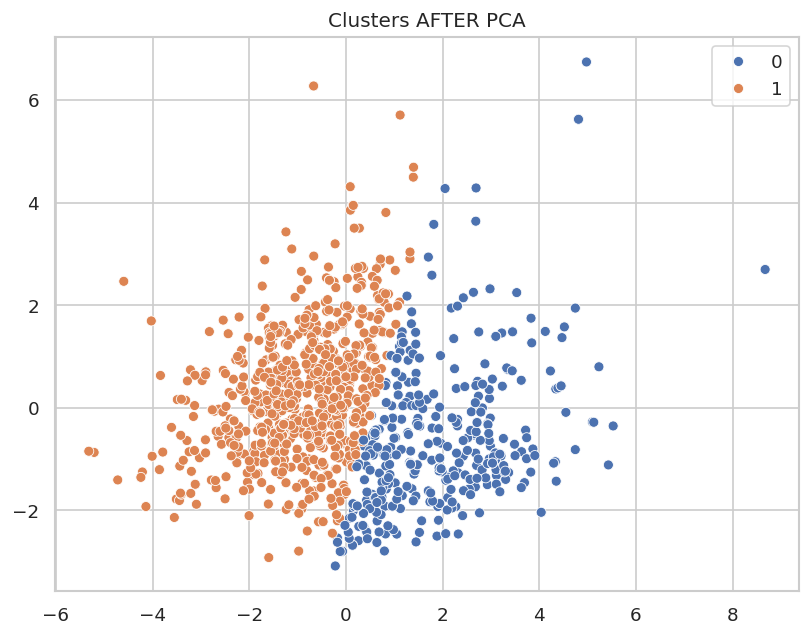

In [23]:
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
labels = kmeans.fit_predict(pca_data)

sns.scatterplot(x=pca_data[:,0], y=pca_data[:,1], hue=labels)
plt.title("Clusters AFTER PCA")
plt.show()

# 12. Centroids
Centroids represent cluster centers.

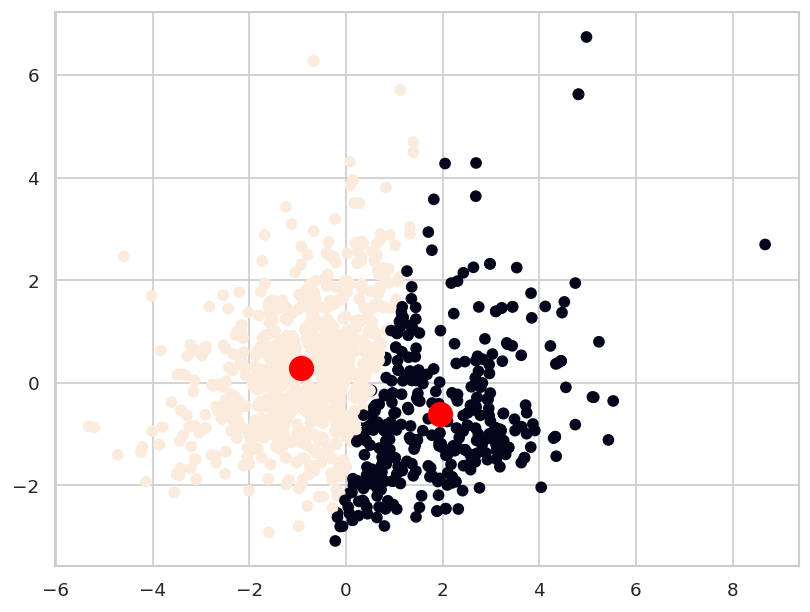

In [24]:
centroids = kmeans.cluster_centers_

plt.scatter(pca_data[:,0], pca_data[:,1], c=labels)
plt.scatter(centroids[:,0], centroids[:,1], c='red', s=200)
plt.show()

# 13. Silhouette Comparison
We compare clustering quality before and after PCA.

In [25]:
print("Before PCA:", silhouette_score(scaled_data, labels_raw))
print("After PCA:", silhouette_score(pca_data, labels))

Before PCA: 0.21981711178387248
After PCA: 0.40469107666370807


# 14. Silhouette Plot
Shows cluster quality for each sample.

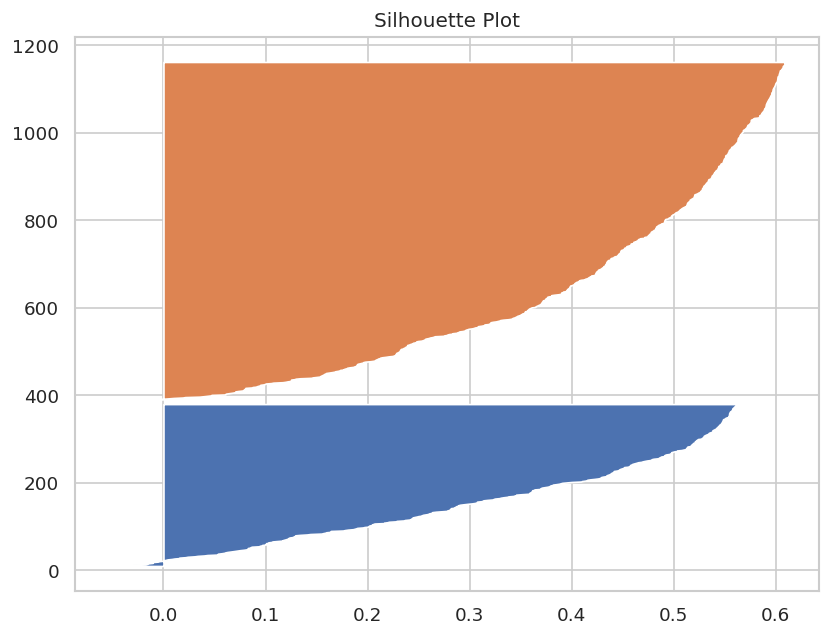

In [26]:
sample_vals = silhouette_samples(pca_data, labels)

plt.figure()
y_lower = 10

for i in range(optimal_k):
    vals = sample_vals[labels == i]
    vals.sort()
    size = len(vals)
    y_upper = y_lower + size
    plt.fill_betweenx(np.arange(y_lower, y_upper), 0, vals)
    y_lower = y_upper + 10

plt.title("Silhouette Plot")
plt.show()

# 15. Cluster Interpretation
Boxplots show feature differences across clusters.

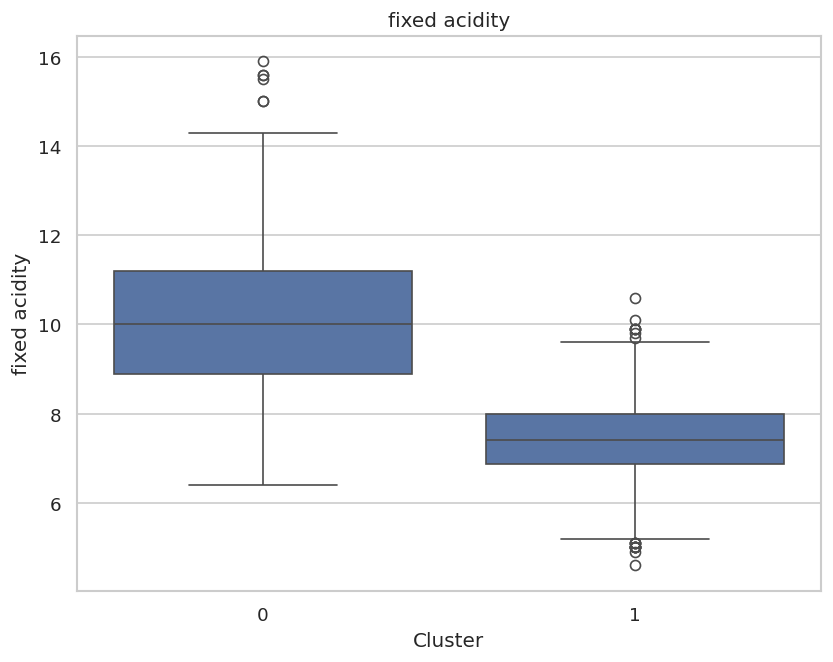

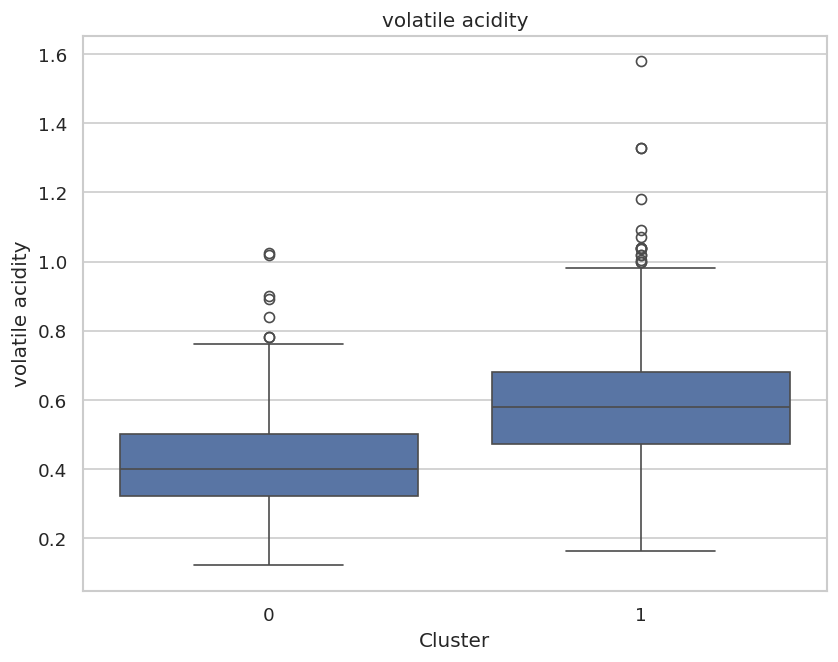

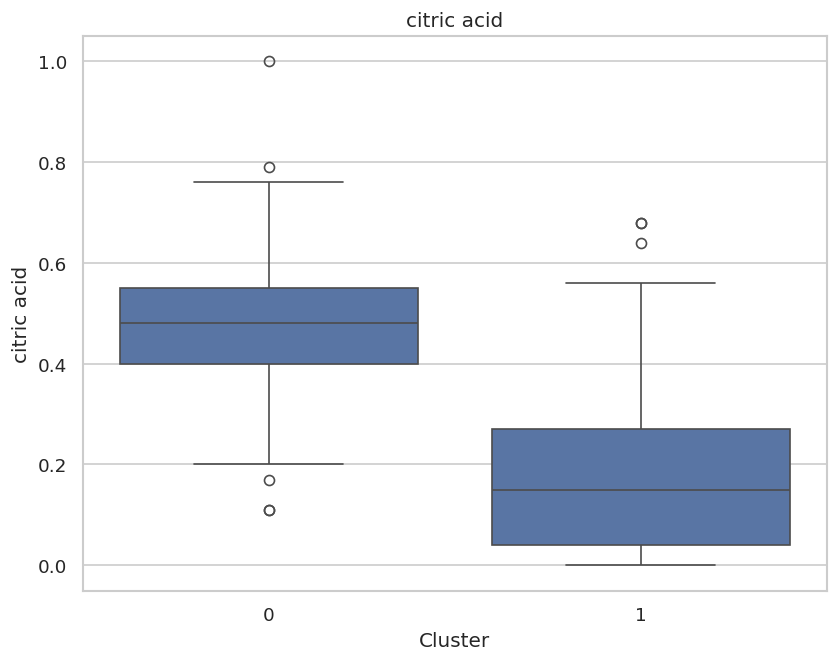

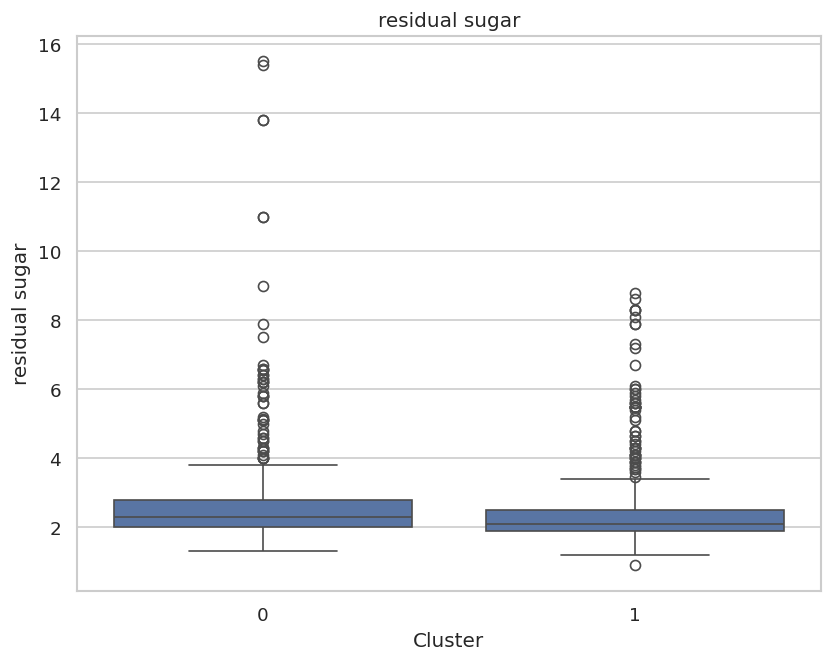

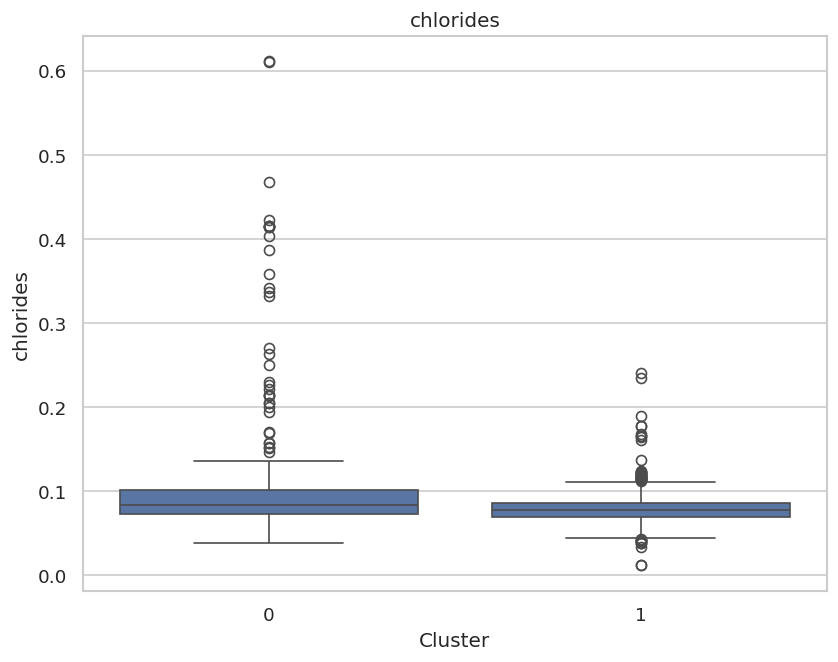

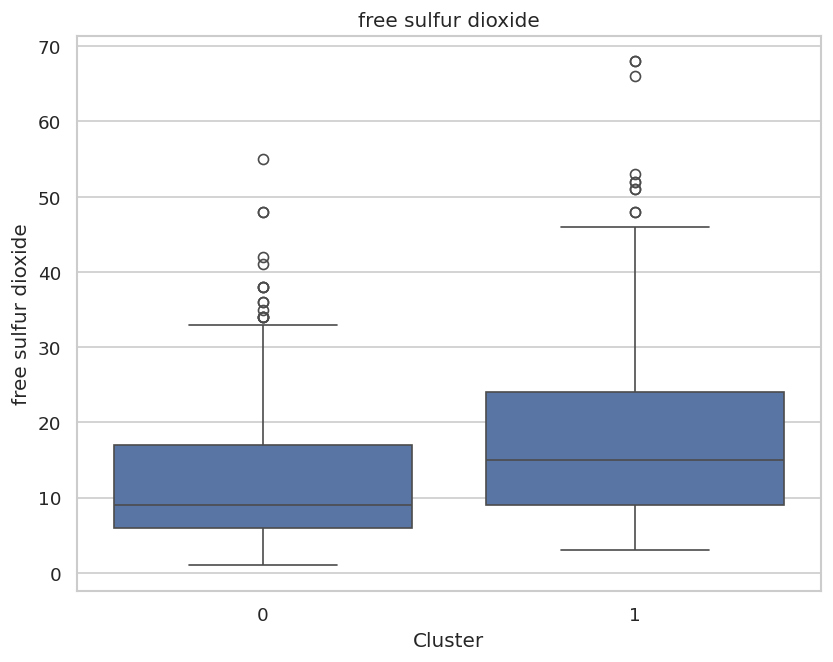

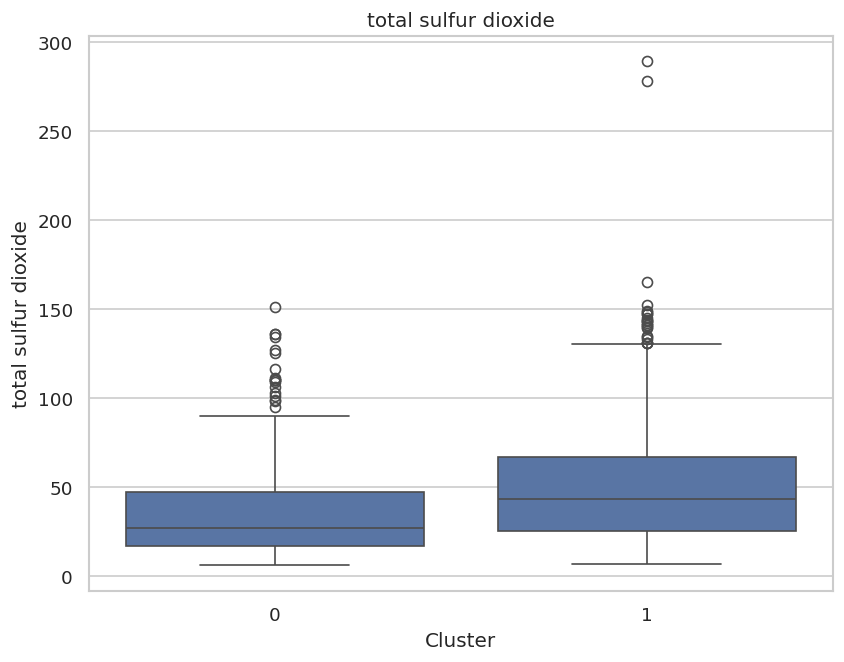

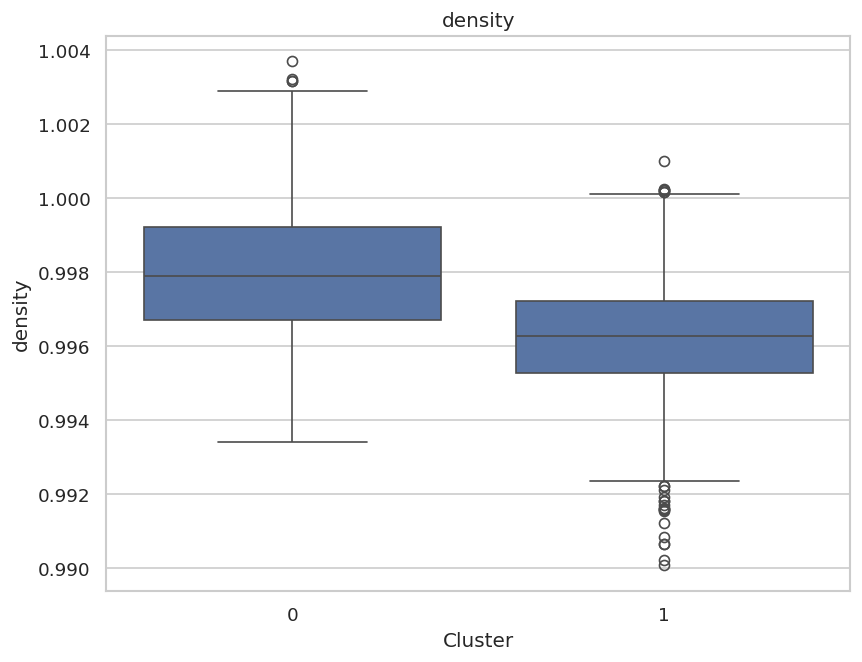

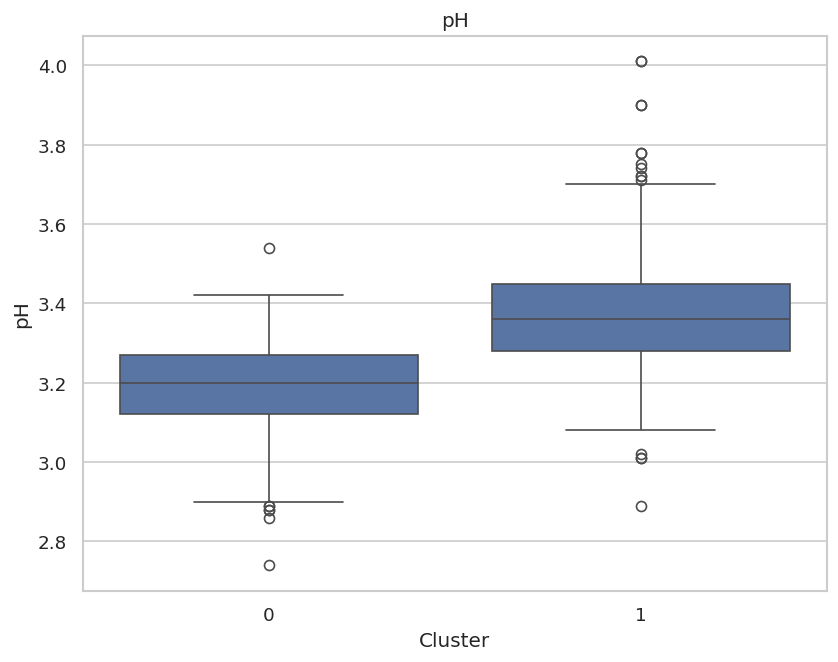

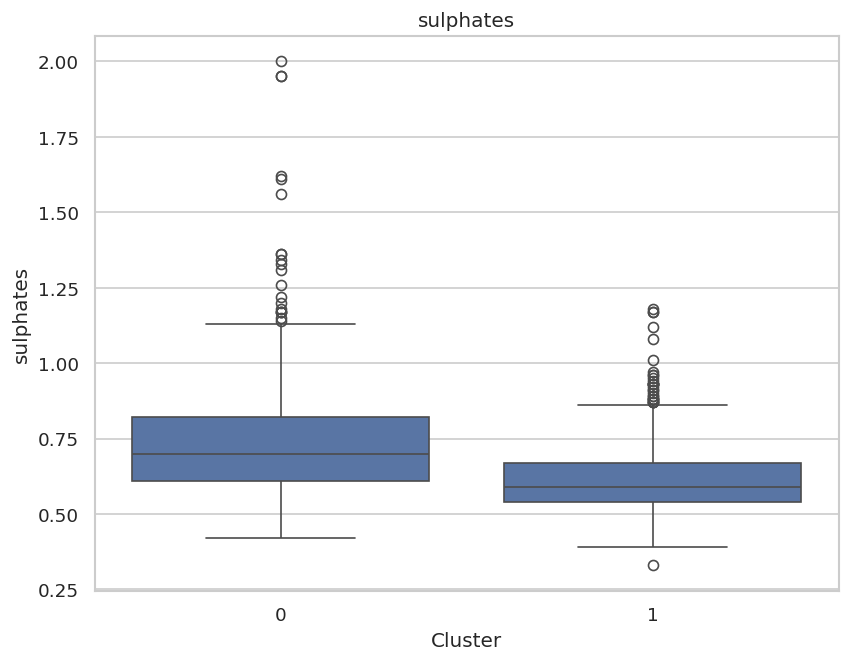

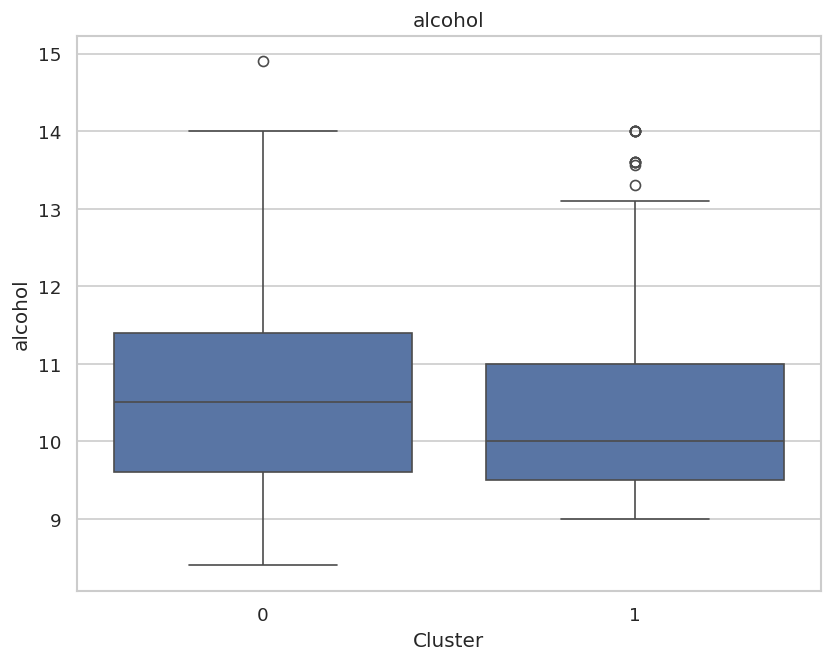

In [27]:
df_features["Cluster"] = labels

for col in df_features.columns[:-1]:
    sns.boxplot(x="Cluster", y=col, data=df_features)
    plt.title(col)
    plt.show()

# 16. PCA Loadings
Shows how features contribute to principal components.

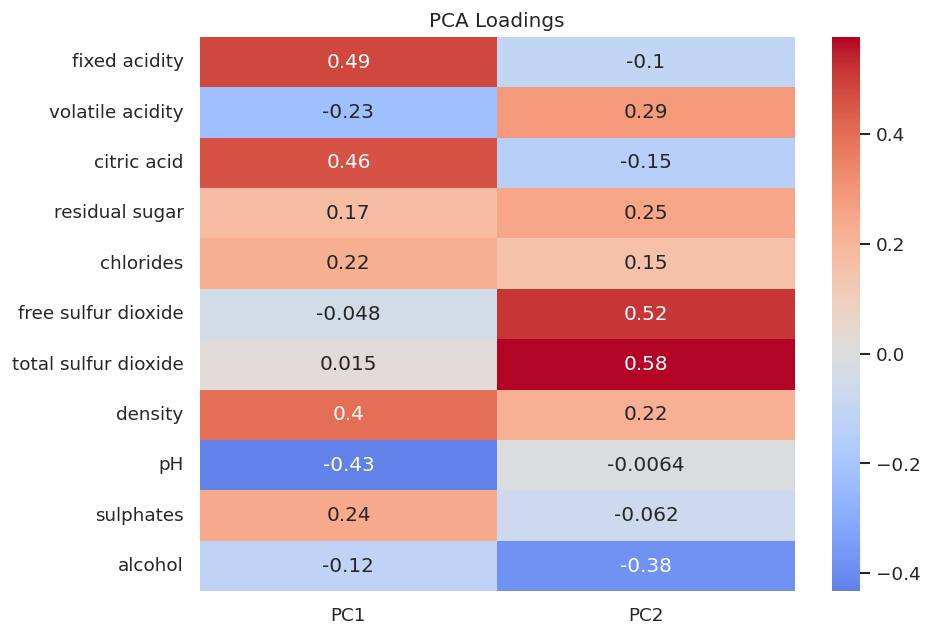

In [28]:
loadings = pd.DataFrame(
    pca_2.components_.T,
    columns=["PC1", "PC2"],
    index=df_features.drop(columns=["Cluster"]).columns
)

sns.heatmap(loadings, annot=True, cmap="coolwarm", center=0)
plt.title("PCA Loadings")
plt.show()

# 17. Conclusion
PCA improves clustering by reducing dimensionality and removing redundancy.

Clustering after PCA shows:
- Better separation
- Higher silhouette scores
- Clearer interpretation

This demonstrates the effectiveness of combining PCA with K-Means.